# Projeto 04: TCC de Mara Oliveira - Análise Micro (Perfil Sociodemográfico)
Neste notebook, utilizamos exclusivamente o arquivo `Candidatos.csv` para analisar a probabilidade de sucesso (Taxa de Conclusão) de acordo com o perfil demográfico do aluno (Cor, Renda, Idade, Gênero) na Rede Federal.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 2. Leitura e Limpeza dos Dados
Vamos carregar os dados, filtrar apenas para os Institutos Federais e remover registros com ausência de informação ('S/I' e 'Não Declarada') para evitar ruídos na análise de perfis.

In [2]:
# Leitura do arquivo
df = pd.read_csv('../Data/Candidatos.csv', sep=';', encoding='utf-8')

# Limpeza de strings
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Filtro para Institutos Federais
df = df[df['Instituicao'].str.startswith('IF', na=False)]

# Remoção de classes sem informação declarada
remover = ['S/I', 'Não Declarada']
df = df[~df['CorRaca'].isin(remover)]
df = df[~df['RendaFamiliar'].isin(remover)]
df = df[~df['FaixaEtaria'].isin(remover)]
df = df[~df['Sexo'].isin(remover)]

print(f"Linhas válidas (após limpeza): {df.shape[0]}")
df.head()

Linhas válidas (após limpeza): 163439


,Ano,Região,UF,Estado,Organização Acadêmica PNP,Instituicao,Instituição (Nome),CorRaca,RendaFamiliar,FaixaEtaria,Sexo,Número de concluintes,Número de ingressantes,Número de Matrículas,Número de vagas
0,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Parda,Não declarada,15 a 19,Feminino,10.0,1.0,40,118.0
1,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Preta,"0<RFP<=0,5",20 a 24,Masculino,11.0,17.0,55,851.0
2,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Indígena,"0<RFP<=0,5",50 a 54,Masculino,NaN,NaN,1,NaN
3,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Indígena,"0<RFP<=0,5",15 a 19,Masculino,NaN,NaN,1,NaN
4,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Preta,"RFP>3,5",20 a 24,Masculino,3.0,7.0,24,464.0


## 3. Agrupamento pelo Perfil Completo
Aqui, nós criamos a 'Unidade de Análise: Perfil', calculando a Taxa de Conclusão (Sucesso) para cada combinação de Cor, Renda, Idade e Sexo na Rede Federal como um todo.

In [3]:
# Agrupando por Perfil Demográfico
perfil_cols = ['CorRaca', 'RendaFamiliar', 'FaixaEtaria', 'Sexo']

# Somamos o total histórico de ingressantes e concluintes para cada perfil
df_perfil = df.groupby(perfil_cols).agg(
    total_ingressantes=('Número de ingressantes', 'sum'),
    total_concluintes=('Número de concluintes', 'sum')
).reset_index()

# Filtramos apenas grupos que tenham uma amostra mínima (ex: mais de 100 alunos no total da rede histórica)
df_perfil = df_perfil[df_perfil['total_ingressantes'] > 100].copy()

# Cálculo da Taxa de Conclusão
df_perfil['taxa_conclusao'] = (df_perfil['total_concluintes'] / df_perfil['total_ingressantes']) * 100

# Criar uma coluna de nome descritivo do perfil para gráficos
df_perfil['Nome_Perfil'] = df_perfil['CorRaca'] + " | " + df_perfil['RendaFamiliar'] + " | " + df_perfil['FaixaEtaria']

df_perfil = df_perfil.sort_values(by='taxa_conclusao', ascending=False)
df_perfil.head()

,CorRaca,RendaFamiliar,FaixaEtaria,Sexo,total_ingressantes,total_concluintes,taxa_conclusao,Nome_Perfil
65,Amarela,"1,5<RFP<=2,5",> 60,Masculino,105.0,97.0,92.380952,"Amarela | 1,5<RFP<=2,5 | > 60"
61,Amarela,"1,5<RFP<=2,5",55 a 59,Masculino,103.0,95.0,92.233010,"Amarela | 1,5<RFP<=2,5 | 55 a 59"
153,Amarela,"RFP>3,5",> 60,Masculino,128.0,117.0,91.406250,"Amarela | RFP>3,5 | > 60"
104,Amarela,"2,5<RFP<=3,5",55 a 59,Feminino,124.0,112.0,90.322581,"Amarela | 2,5<RFP<=3,5 | 55 a 59"
82,Amarela,"1<RFP<=1,5",55 a 59,Feminino,155.0,140.0,90.322581,"Amarela | 1<RFP<=1,5 | 55 a 59"


## 4. Ranking de Sucesso por Perfil (Maiores vs Menores)

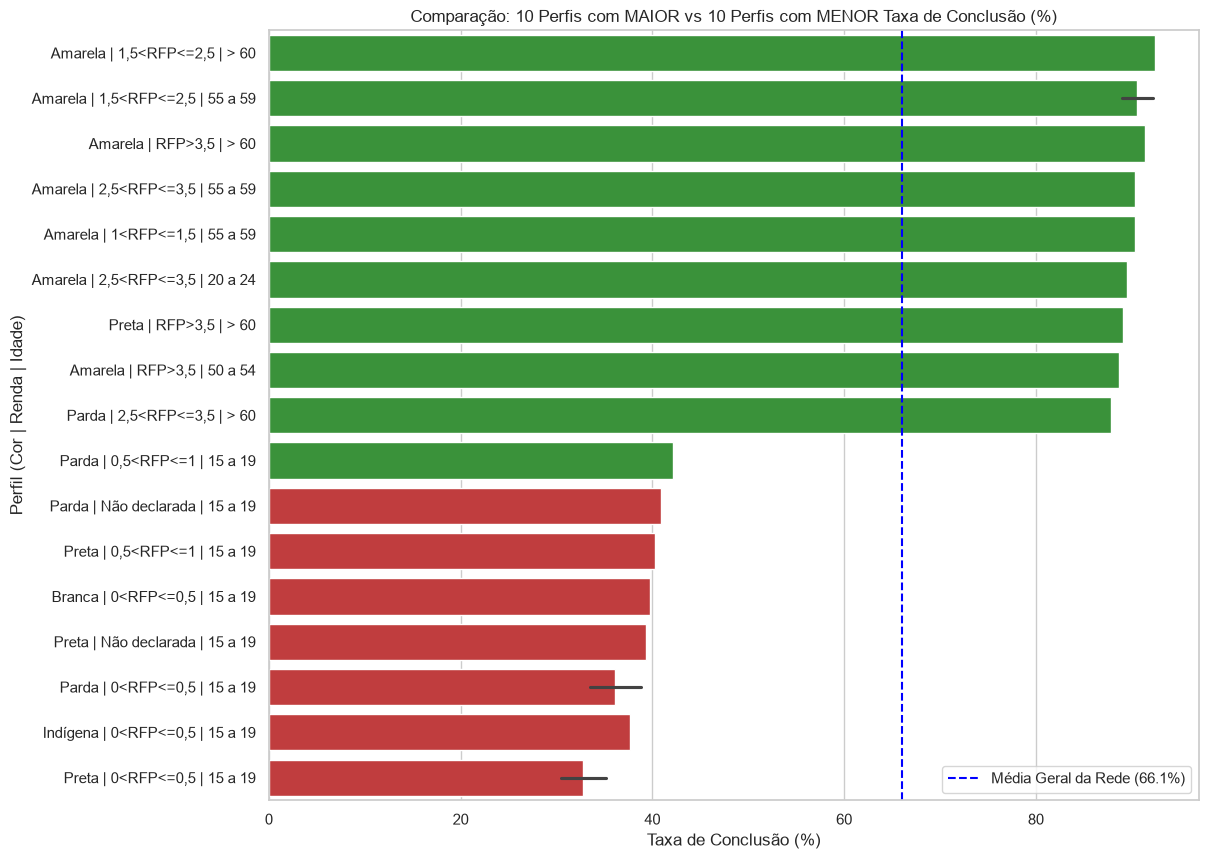

In [4]:
# Selecionar os 10 maiores e os 10 menores
top_10 = df_perfil.head(10).copy()
bottom_10 = df_perfil.tail(10).copy()

# Concatenar para um único DataFrame
df_extremos = pd.concat([top_10, bottom_10])

# Criar paleta condicional (verde para os 10 maiores, vermelho para os 10 menores)
cores = ['#2ca02c'] * 10 + ['#d62728'] * 10

plt.figure(figsize=(12, 10))
sns.barplot(data=df_extremos, x='taxa_conclusao', y='Nome_Perfil', palette=cores)
plt.title('Comparação: 10 Perfis com MAIOR vs 10 Perfis com MENOR Taxa de Conclusão (%)')
plt.xlabel('Taxa de Conclusão (%)')
plt.ylabel('Perfil (Cor | Renda | Idade)')

# Linha de média geral
media_geral = (df['Número de concluintes'].sum() / df['Número de ingressantes'].sum()) * 100
plt.axvline(media_geral, color='blue', linestyle='--', label=f'Média Geral da Rede ({media_geral:.1f}%)')
plt.legend()
plt.show()

## 5. Análise Isolada do Impacto Sociodemográfico
Agrupando todos os alunos para analisar o impacto isolado da Renda, da Cor/Raça e da Faixa Etária na Taxa de Conclusão.

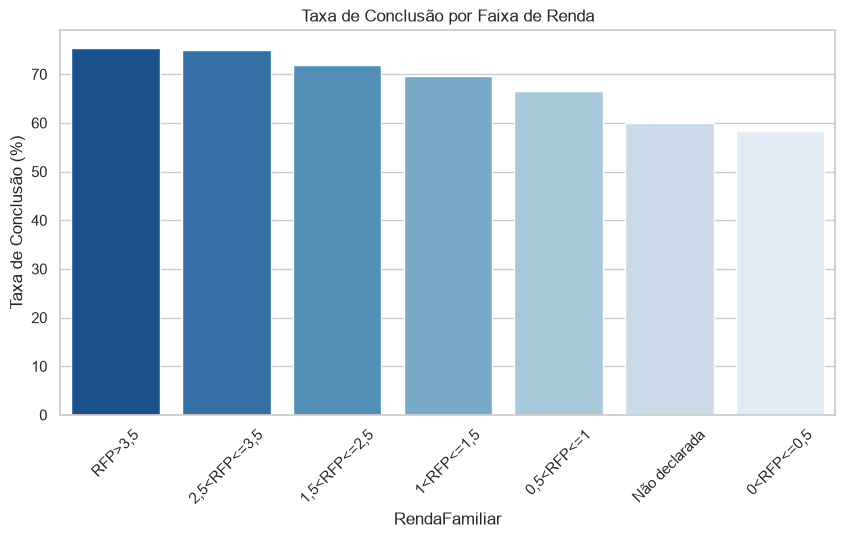

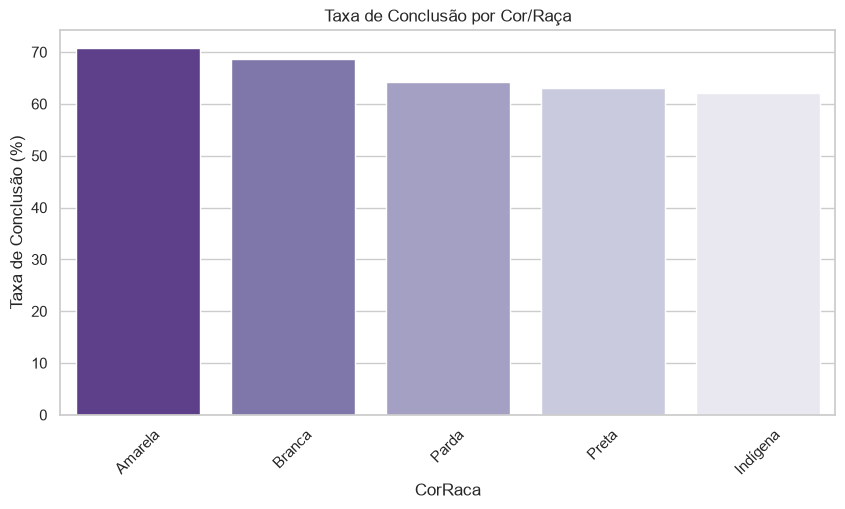

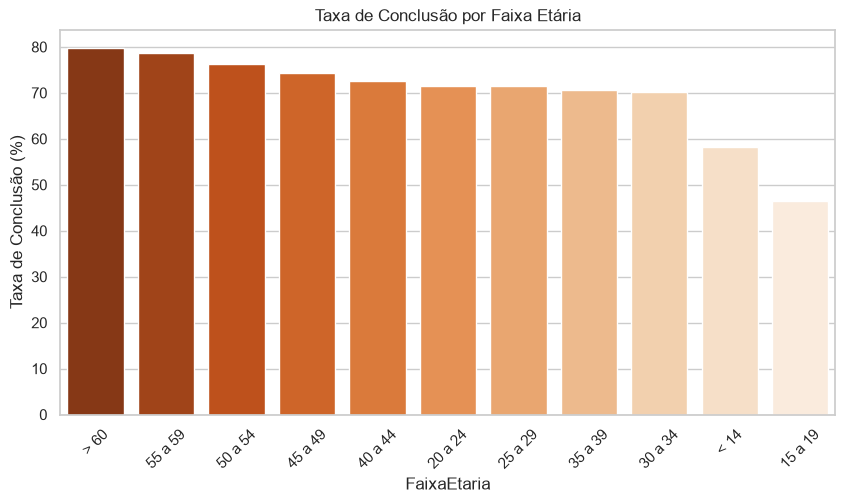

In [5]:
# 1. Isolado por Renda
df_renda = df.groupby('RendaFamiliar').agg(
    ingressantes=('Número de ingressantes', 'sum'),
    concluintes=('Número de concluintes', 'sum')
).reset_index()
df_renda['taxa_conclusao'] = (df_renda['concluintes'] / df_renda['ingressantes']) * 100
df_renda = df_renda.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_renda, x='RendaFamiliar', y='taxa_conclusao', palette='Blues_r')
plt.title('Taxa de Conclusão por Faixa de Renda')
plt.xticks(rotation=45)
plt.ylabel('Taxa de Conclusão (%)')
plt.show()

# 2. Isolado por Cor/Raça
df_cor = df.groupby('CorRaca').agg(
    ingressantes=('Número de ingressantes', 'sum'),
    concluintes=('Número de concluintes', 'sum')
).reset_index()
df_cor['taxa_conclusao'] = (df_cor['concluintes'] / df_cor['ingressantes']) * 100
df_cor = df_cor.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_cor, x='CorRaca', y='taxa_conclusao', palette='Purples_r')
plt.title('Taxa de Conclusão por Cor/Raça')
plt.xticks(rotation=45)
plt.ylabel('Taxa de Conclusão (%)')
plt.show()

# 3. Isolado por Faixa Etária
df_idade = df.groupby('FaixaEtaria').agg(
    ingressantes=('Número de ingressantes', 'sum'),
    concluintes=('Número de concluintes', 'sum')
).reset_index()
df_idade['taxa_conclusao'] = (df_idade['concluintes'] / df_idade['ingressantes']) * 100
df_idade = df_idade.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_idade, x='FaixaEtaria', y='taxa_conclusao', palette='Oranges_r')
plt.title('Taxa de Conclusão por Faixa Etária')
plt.xticks(rotation=45)
plt.ylabel('Taxa de Conclusão (%)')
plt.show()

## 6. Interseccionalidade: Matriz de Calor (Cor vs Renda)
Vamos cruzar Cor e Renda, ignorando as demais variáveis, para ver como elas interagem estruturalmente.

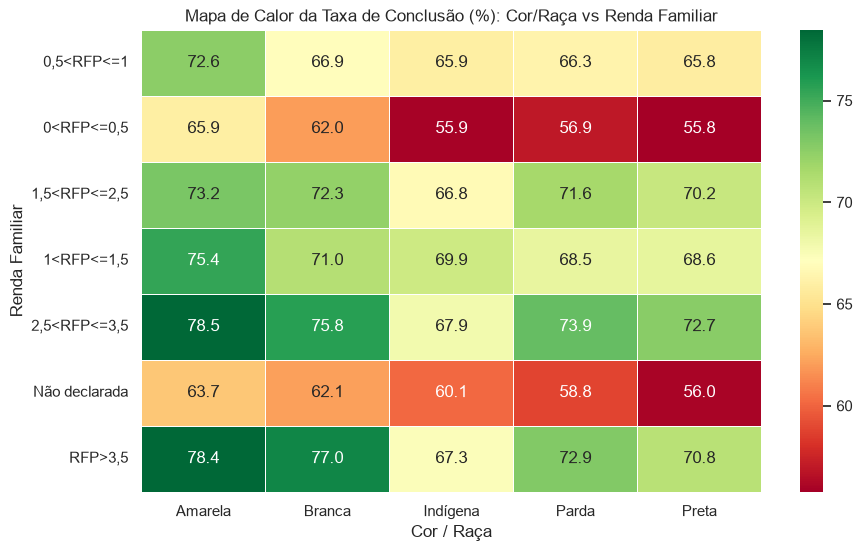

In [6]:
df_intersec = df.groupby(['CorRaca', 'RendaFamiliar']).agg(
    ingressantes=('Número de ingressantes', 'sum'),
    concluintes=('Número de concluintes', 'sum')
).reset_index()

df_intersec = df_intersec[df_intersec['ingressantes'] > 50].copy()
df_intersec['taxa_conclusao'] = (df_intersec['concluintes'] / df_intersec['ingressantes']) * 100

pivot = df_intersec.pivot(index='RendaFamiliar', columns='CorRaca', values='taxa_conclusao')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt=".1f", linewidths=.5)
plt.title('Mapa de Calor da Taxa de Conclusão (%): Cor/Raça vs Renda Familiar')
plt.ylabel('Renda Familiar')
plt.xlabel('Cor / Raça')
plt.show()

## 7. Teste de Significância Estatística (Qui-Quadrado)
Para comprovar cientificamente que as diferenças nas taxas de conclusão não são obras do acaso, aplicamos o teste Qui-Quadrado de Independência. Comparamos o número de alunos que concluíram vs não concluíram (evadiram/retiveram) em cada categoria.

In [7]:
from scipy.stats import chi2_contingency

def testar_significancia(df_base, coluna_grupo):
    df_grupo = df_base.groupby(coluna_grupo).agg(
        ingressantes=('Número de ingressantes', 'sum'),
        concluintes=('Número de concluintes', 'sum')
    ).reset_index()
    
    # Calcular não concluintes
    df_grupo['nao_concluintes'] = df_grupo['ingressantes'] - df_grupo['concluintes']
    
    # Tabela de contingência
    tabela_contingencia = df_grupo[['concluintes', 'nao_concluintes']].values
    
    chi2, p, dof, expected = chi2_contingency(tabela_contingencia)
    
    print(f"--- Teste para a variável: {coluna_grupo} ---")
    print(f"Valor-p (p-value): {p:.2e}")
    if p < 0.05:
        print("Resultado: Estatisticamente SIGNIFICATIVA! (A diferença não é ao acaso)\n")
    else:
        print("Resultado: NÃO significativa. (As variações podem ser ao acaso)\n")

testar_significancia(df, 'RendaFamiliar')
testar_significancia(df, 'CorRaca')
testar_significancia(df, 'FaixaEtaria')

--- Teste para a variável: RendaFamiliar ---
Valor-p (p-value): 0.00e+00
Resultado: Estatisticamente SIGNIFICATIVA! (A diferença não é ao acaso)

--- Teste para a variável: CorRaca ---
Valor-p (p-value): 0.00e+00
Resultado: Estatisticamente SIGNIFICATIVA! (A diferença não é ao acaso)

--- Teste para a variável: FaixaEtaria ---
Valor-p (p-value): 0.00e+00
Resultado: Estatisticamente SIGNIFICATIVA! (A diferença não é ao acaso)



## 8. Análise de Correspondência Múltipla (ACM)
Para visualizar a associação multidimensional entre as categorias de perfil (Cor/Raça, Renda, Idade, Gênero) e a situação de conclusão do aluno, aplicamos a Análise de Correspondência Múltipla (ACM).

### Justificativa da Correção de Benzécri
Na ACM clássica, a variância explicada (inércia) pelas primeiras dimensões é tipicamente subestimada devido à expansão da matriz de dados para uma matriz indicadora binária (dummy), que infla artificialmente a inércia total. Para mitigar esse efeito e apresentar um percentual mais realista e rigoroso da variância explicada pelas principais dimensões no relatório de TCC, aplicamos a **Correção de Benzécri** nos autovalores do modelo.

In [8]:
import prince

# 1. Preparar os dados expandindo a contagem para registros individuais
perfil_cols = ['CorRaca', 'RendaFamiliar', 'FaixaEtaria', 'Sexo']

# Agrupar pelos perfis para consolidar e limpar
df_agrupado = df.groupby(perfil_cols).agg(
    ingressantes=('Número de ingressantes', 'sum'),
    concluintes=('Número de concluintes', 'sum')
).reset_index()

# Filtramos apenas perfis com amostra representativa (mais de 100 ingressantes historicamente)
df_agrupado = df_agrupado[df_agrupado['ingressantes'] > 100].copy()

# Criar lista de registros individuais
registros = []
for idx, row in df_agrupado.iterrows():
    c = int(row['concluintes'])
    nc = int(row['ingressantes'] - row['concluintes'])
    
    # Criamos os registros individuais
    for _ in range(c):
        registros.append({
            'CorRaca': row['CorRaca'],
            'RendaFamiliar': row['RendaFamiliar'],
            'FaixaEtaria': row['FaixaEtaria'],
            'Sexo': row['Sexo'],
            'Situacao': 'Concluinte'
        })
    for _ in range(nc):
        registros.append({
            'CorRaca': row['CorRaca'],
            'RendaFamiliar': row['RendaFamiliar'],
            'FaixaEtaria': row['FaixaEtaria'],
            'Sexo': row['Sexo'],
            'Situacao': 'Não Concluinte'
        })

df_individual = pd.DataFrame(registros)
print(f"Total de registros individuais gerados para a ACM: {len(df_individual)}")
df_individual.head()

Total de registros individuais gerados para a ACM: 5874832


,CorRaca,RendaFamiliar,FaixaEtaria,Sexo,Situacao
0,Amarela,"0,5<RFP<=1",15 a 19,Feminino,Concluinte
1,Amarela,"0,5<RFP<=1",15 a 19,Feminino,Concluinte
2,Amarela,"0,5<RFP<=1",15 a 19,Feminino,Concluinte
3,Amarela,"0,5<RFP<=1",15 a 19,Feminino,Concluinte
4,Amarela,"0,5<RFP<=1",15 a 19,Feminino,Concluinte


In [9]:
# 2. Instanciar e ajustar o modelo ACM com a Correção de Benzécri
# A correção de Benzécri ajusta os autovalores (eigenvalues) para corrigir a subestimação
# da inércia explicada gerada pela matriz indicadora binária.
mca = prince.MCA(
    n_components=2,
    n_iter=5,
    copy=True,
    check_input=True,
    engine='sklearn',
    correction='benzecri',  # Aplica a correção de Benzécri nativamente
    random_state=42
)
mca = mca.fit(df_individual)

# 3. Obter as coordenadas das categorias
col_coords = mca.column_coordinates(df_individual)
col_coords.columns = ['Dim 1', 'Dim 2']

# Inércia explicada (com correção de Benzécri já aplicada)
percent_expl = mca.percentage_of_variance_
print(f"Inércia explicada na Dim 1 (Corrigida por Benzécri): {percent_expl[0]:.2f}%")
print(f"Inércia explicada na Dim 2 (Corrigida por Benzécri): {percent_expl[1]:.2f}%")
col_coords.head()

Inércia explicada na Dim 1 (Corrigida por Benzécri): 85.14%
Inércia explicada na Dim 2 (Corrigida por Benzécri): 14.86%


,Dim 1,Dim 2
CorRaca__Amarela,0.265194,-1.433720
CorRaca__Branca,0.459097,0.378603
CorRaca__Indígena,-1.010198,-1.684614
CorRaca__Parda,-0.401035,-0.097011
CorRaca__Preta,-0.179867,-0.786243


findfont: Failed to find font weight semibold, now using 700.


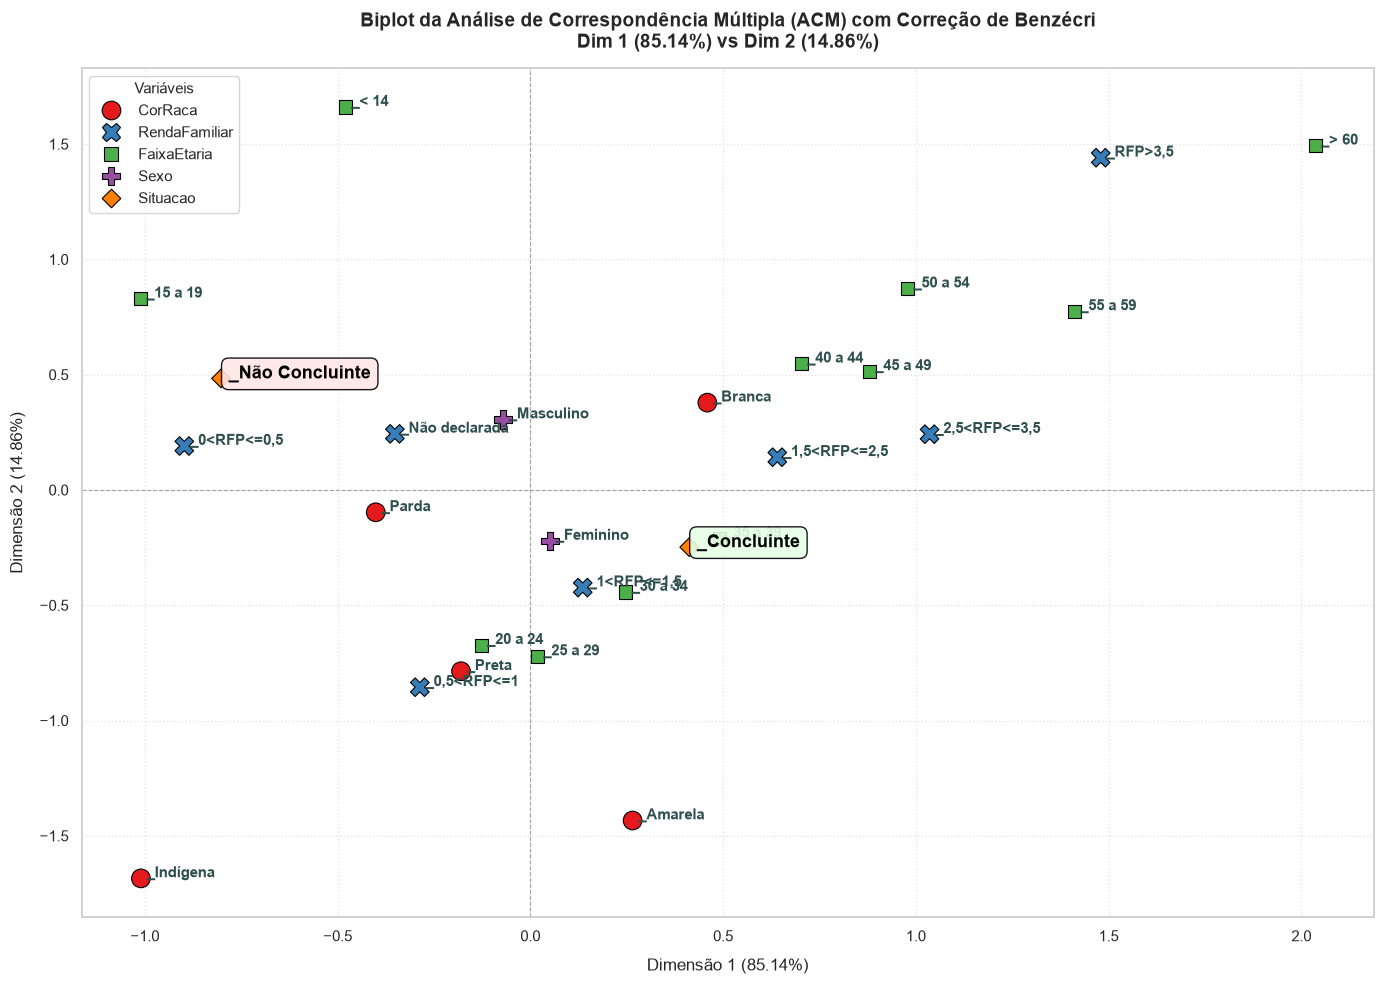

In [10]:
# 4. Plotar o Biplot com matplotlib e seaborn
plt.figure(figsize=(14, 10))

# Processar os labels do índice para melhor apresentação visual
categorias = col_coords.index.tolist()
variaveis = []
labels_limpos = []

for cat in categorias:
    for var in ['CorRaca', 'RendaFamiliar', 'FaixaEtaria', 'Sexo', 'Situacao']:
        if cat.startswith(var):
            variaveis.append(var)
            labels_limpos.append(cat.replace(var + '_', ''))
            break
    else:
        variaveis.append('Outros')
        labels_limpos.append(cat)

col_coords['Variavel'] = variaveis
col_coords['Label_Limpa'] = labels_limpos

# Plot dos pontos
sns.scatterplot(
    data=col_coords, 
    x='Dim 1', 
    y='Dim 2', 
    hue='Variavel', 
    style='Variavel', 
    s=180, 
    palette='Set1',
    edgecolor='black',
    linewidth=0.8
)

# Adicionar labels textuais
for idx, row in col_coords.iterrows():
    if row['Variavel'] == 'Situacao':
        # Destacar os desfechos Concluinte / Não Concluinte
        cor_fundo = '#ffe6e6' if 'Não' in row['Label_Limpa'] else '#e6ffe6'
        plt.text(
            row['Dim 1'] + 0.02, 
            row['Dim 2'], 
            row['Label_Limpa'], 
            fontsize=13, 
            weight='bold', 
            color='black',
            bbox=dict(facecolor=cor_fundo, edgecolor='black', alpha=0.9, boxstyle='round,pad=0.4')
        )
    else:
        plt.text(
            row['Dim 1'] + 0.015, 
            row['Dim 2'] + 0.005, 
            row['Label_Limpa'], 
            fontsize=10.5, 
            color='darkslategray',
            weight='semibold'
        )

# Desenhar eixos centrais
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.title(f'Biplot da Análise de Correspondência Múltipla (ACM) com Correção de Benzécri\nDim 1 ({percent_expl[0]:.2f}%) vs Dim 2 ({percent_expl[1]:.2f}%)', fontsize=14, weight='bold', pad=15)
plt.xlabel(f'Dimensão 1 ({percent_expl[0]:.2f}%)', fontsize=12, labelpad=10)
plt.ylabel(f'Dimensão 2 ({percent_expl[1]:.2f}%)', fontsize=12, labelpad=10)
plt.legend(title='Variáveis', title_fontsize='11', loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()